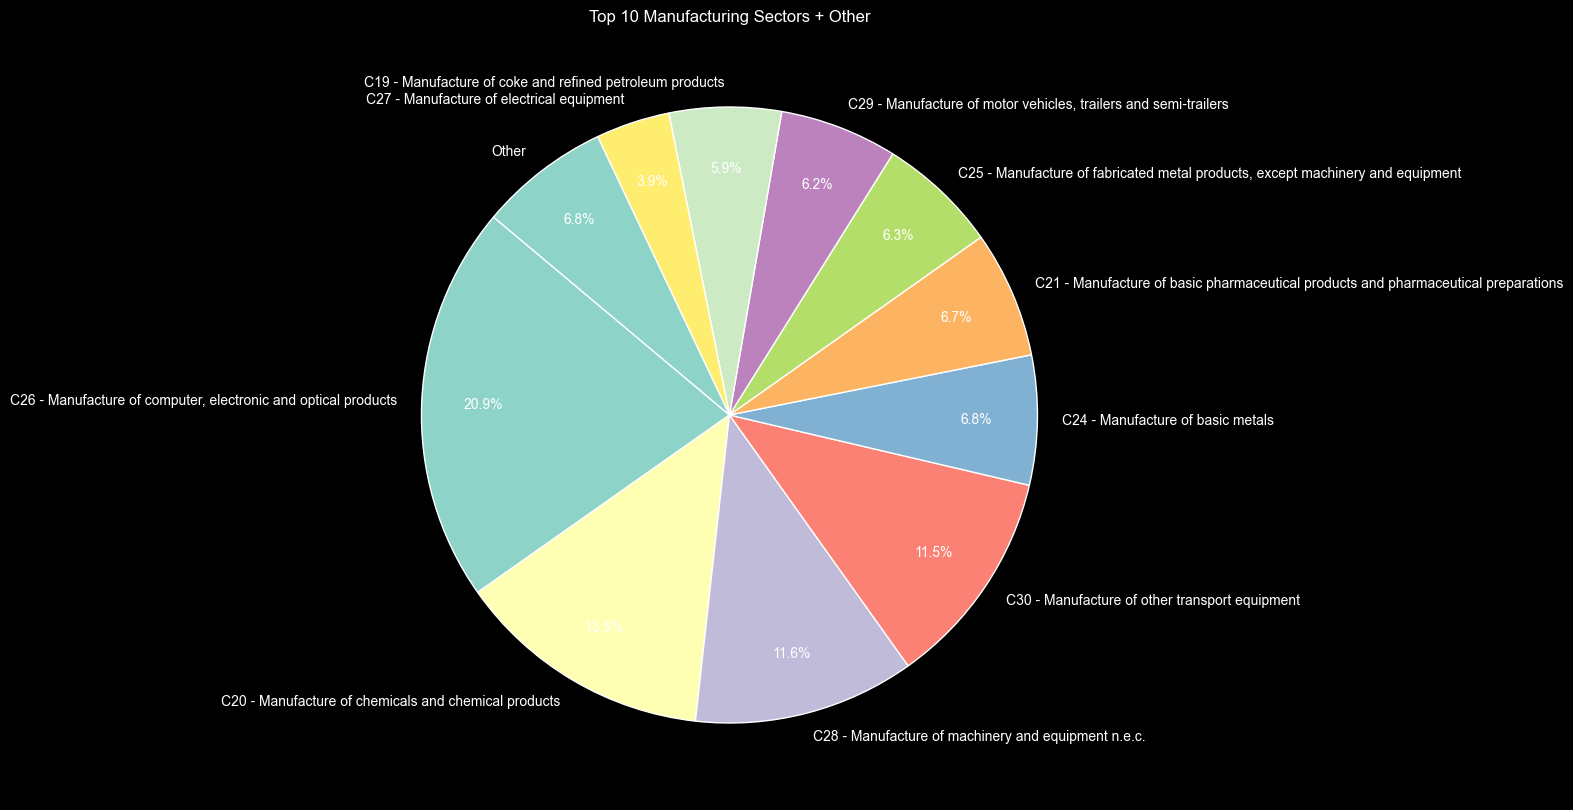

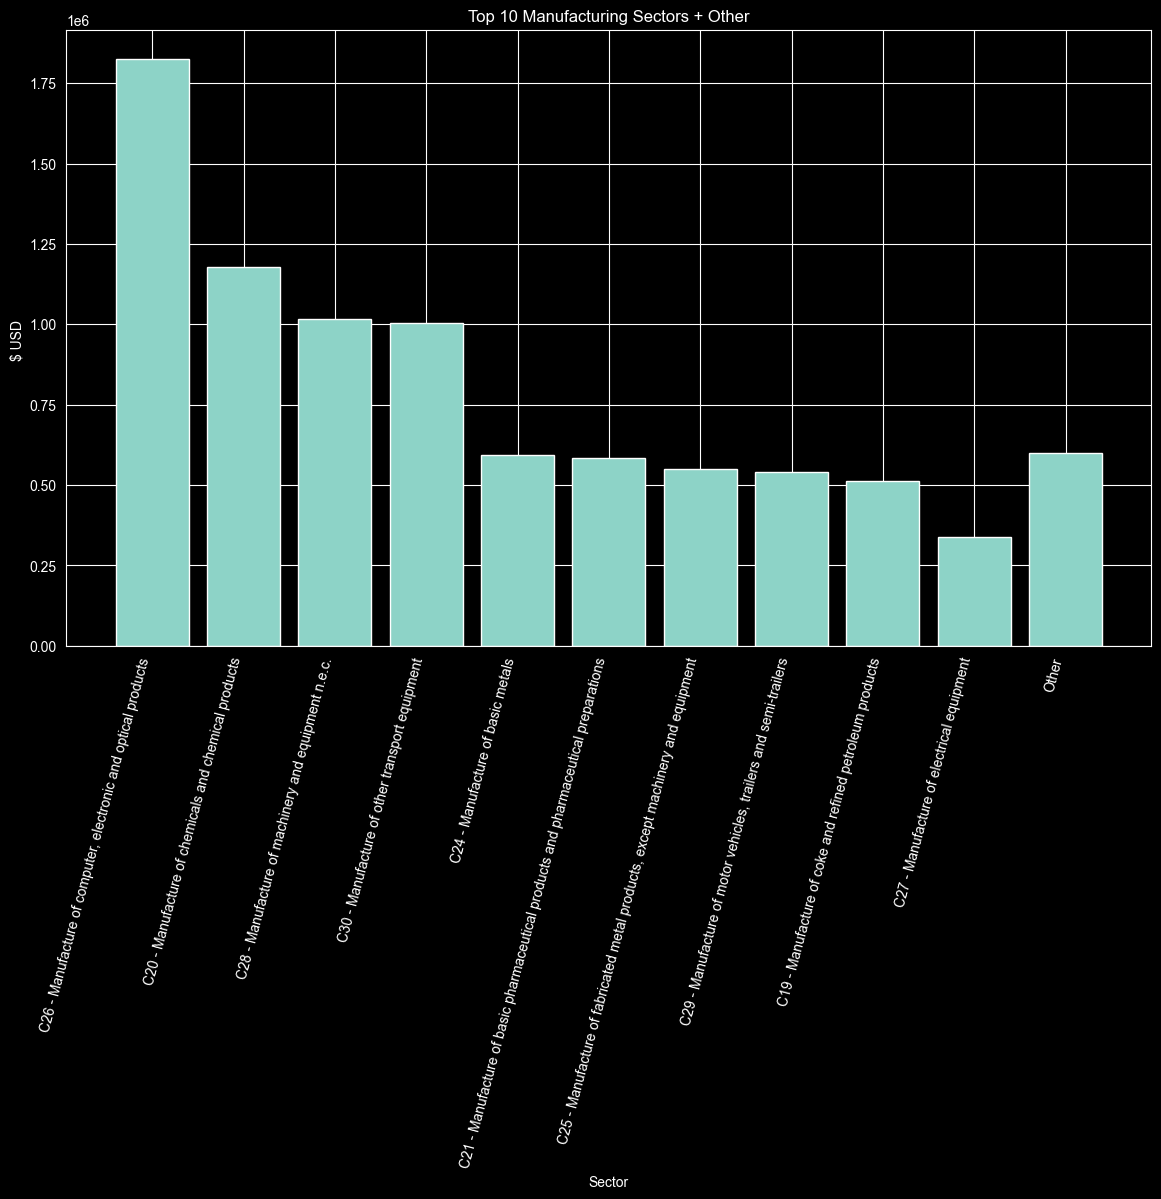

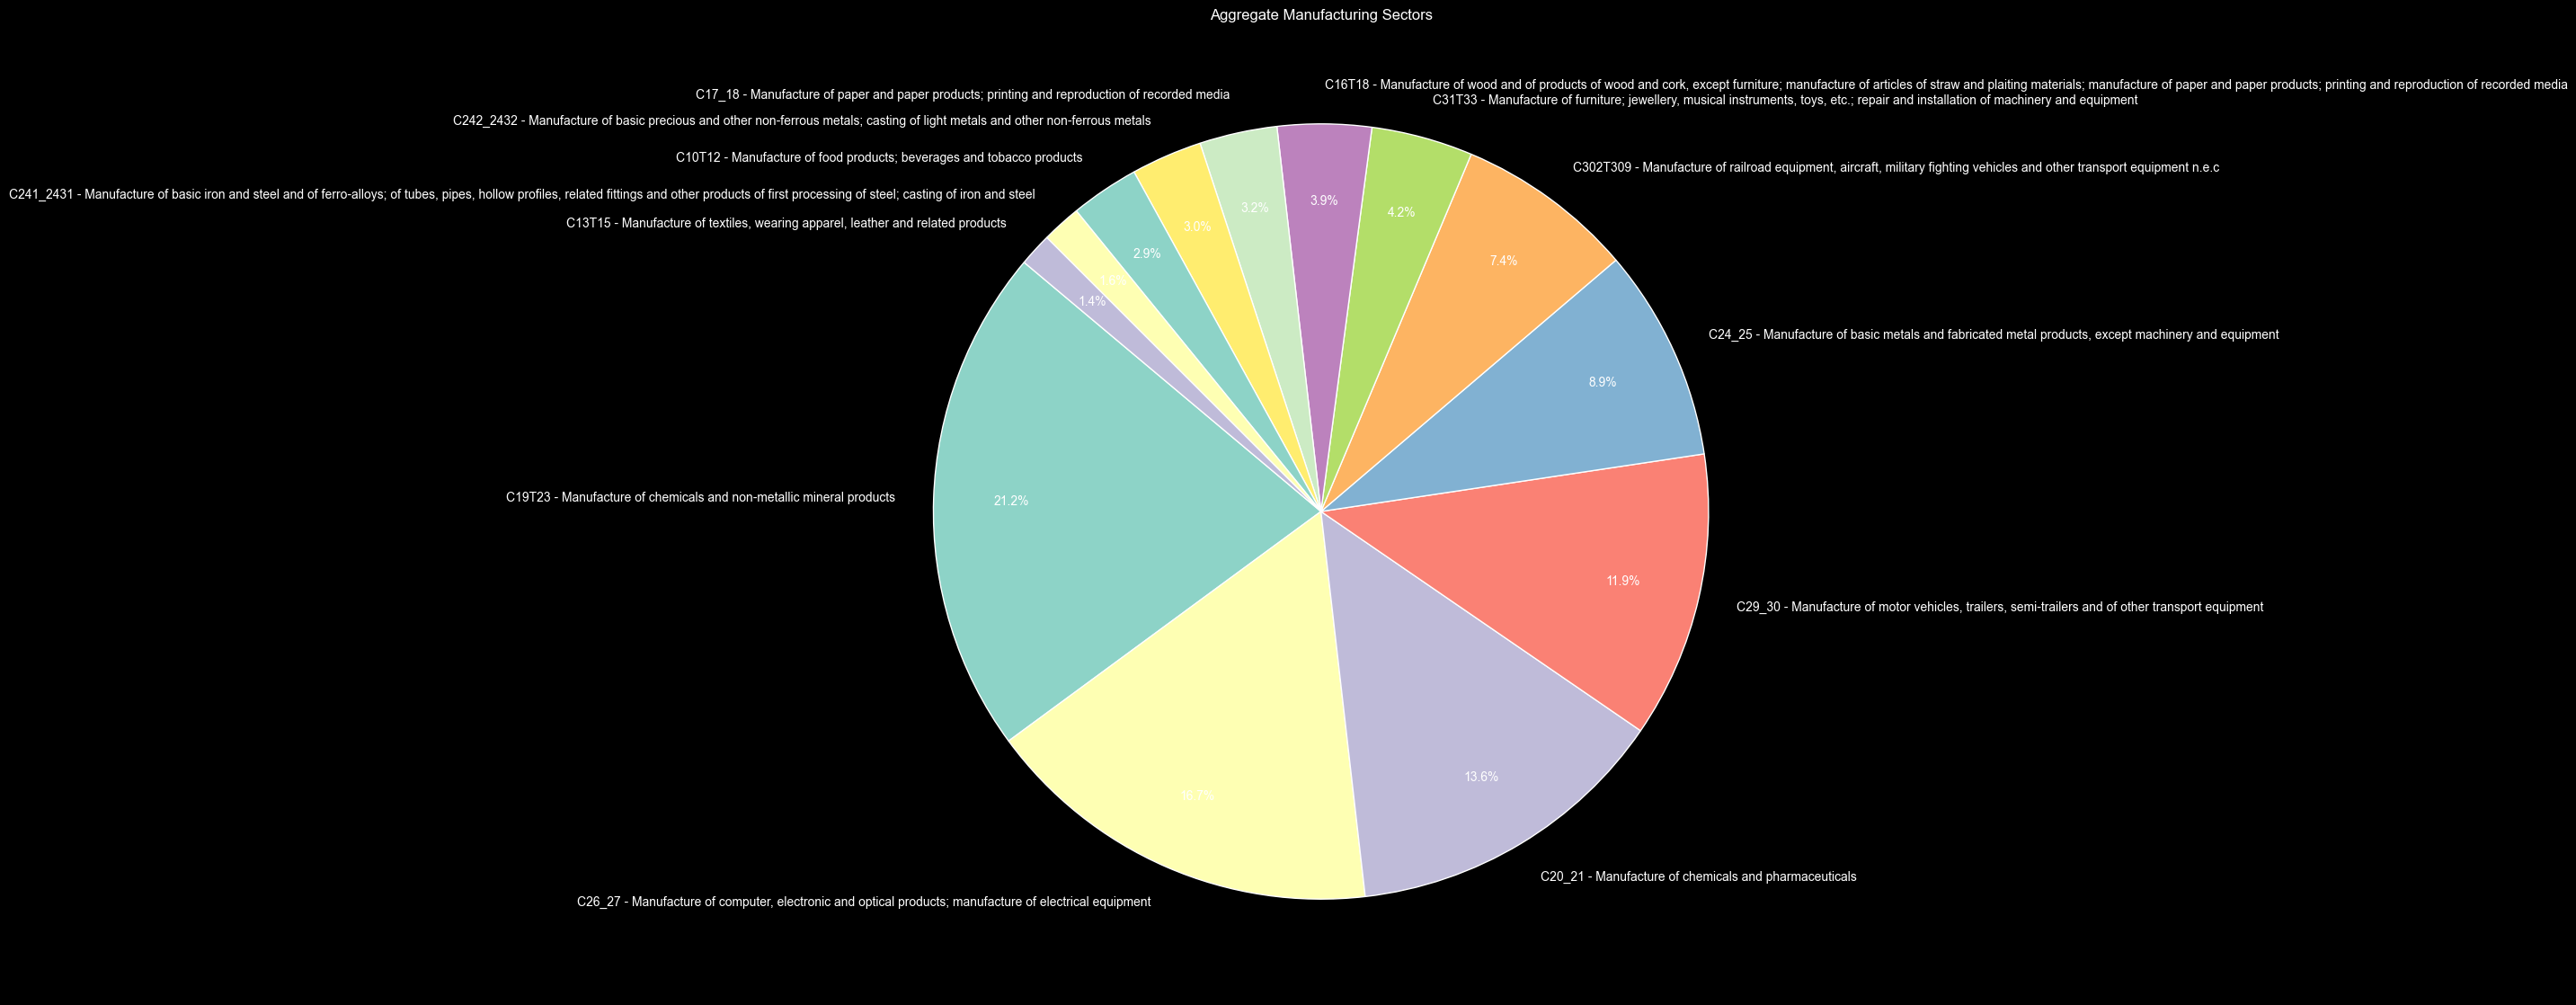

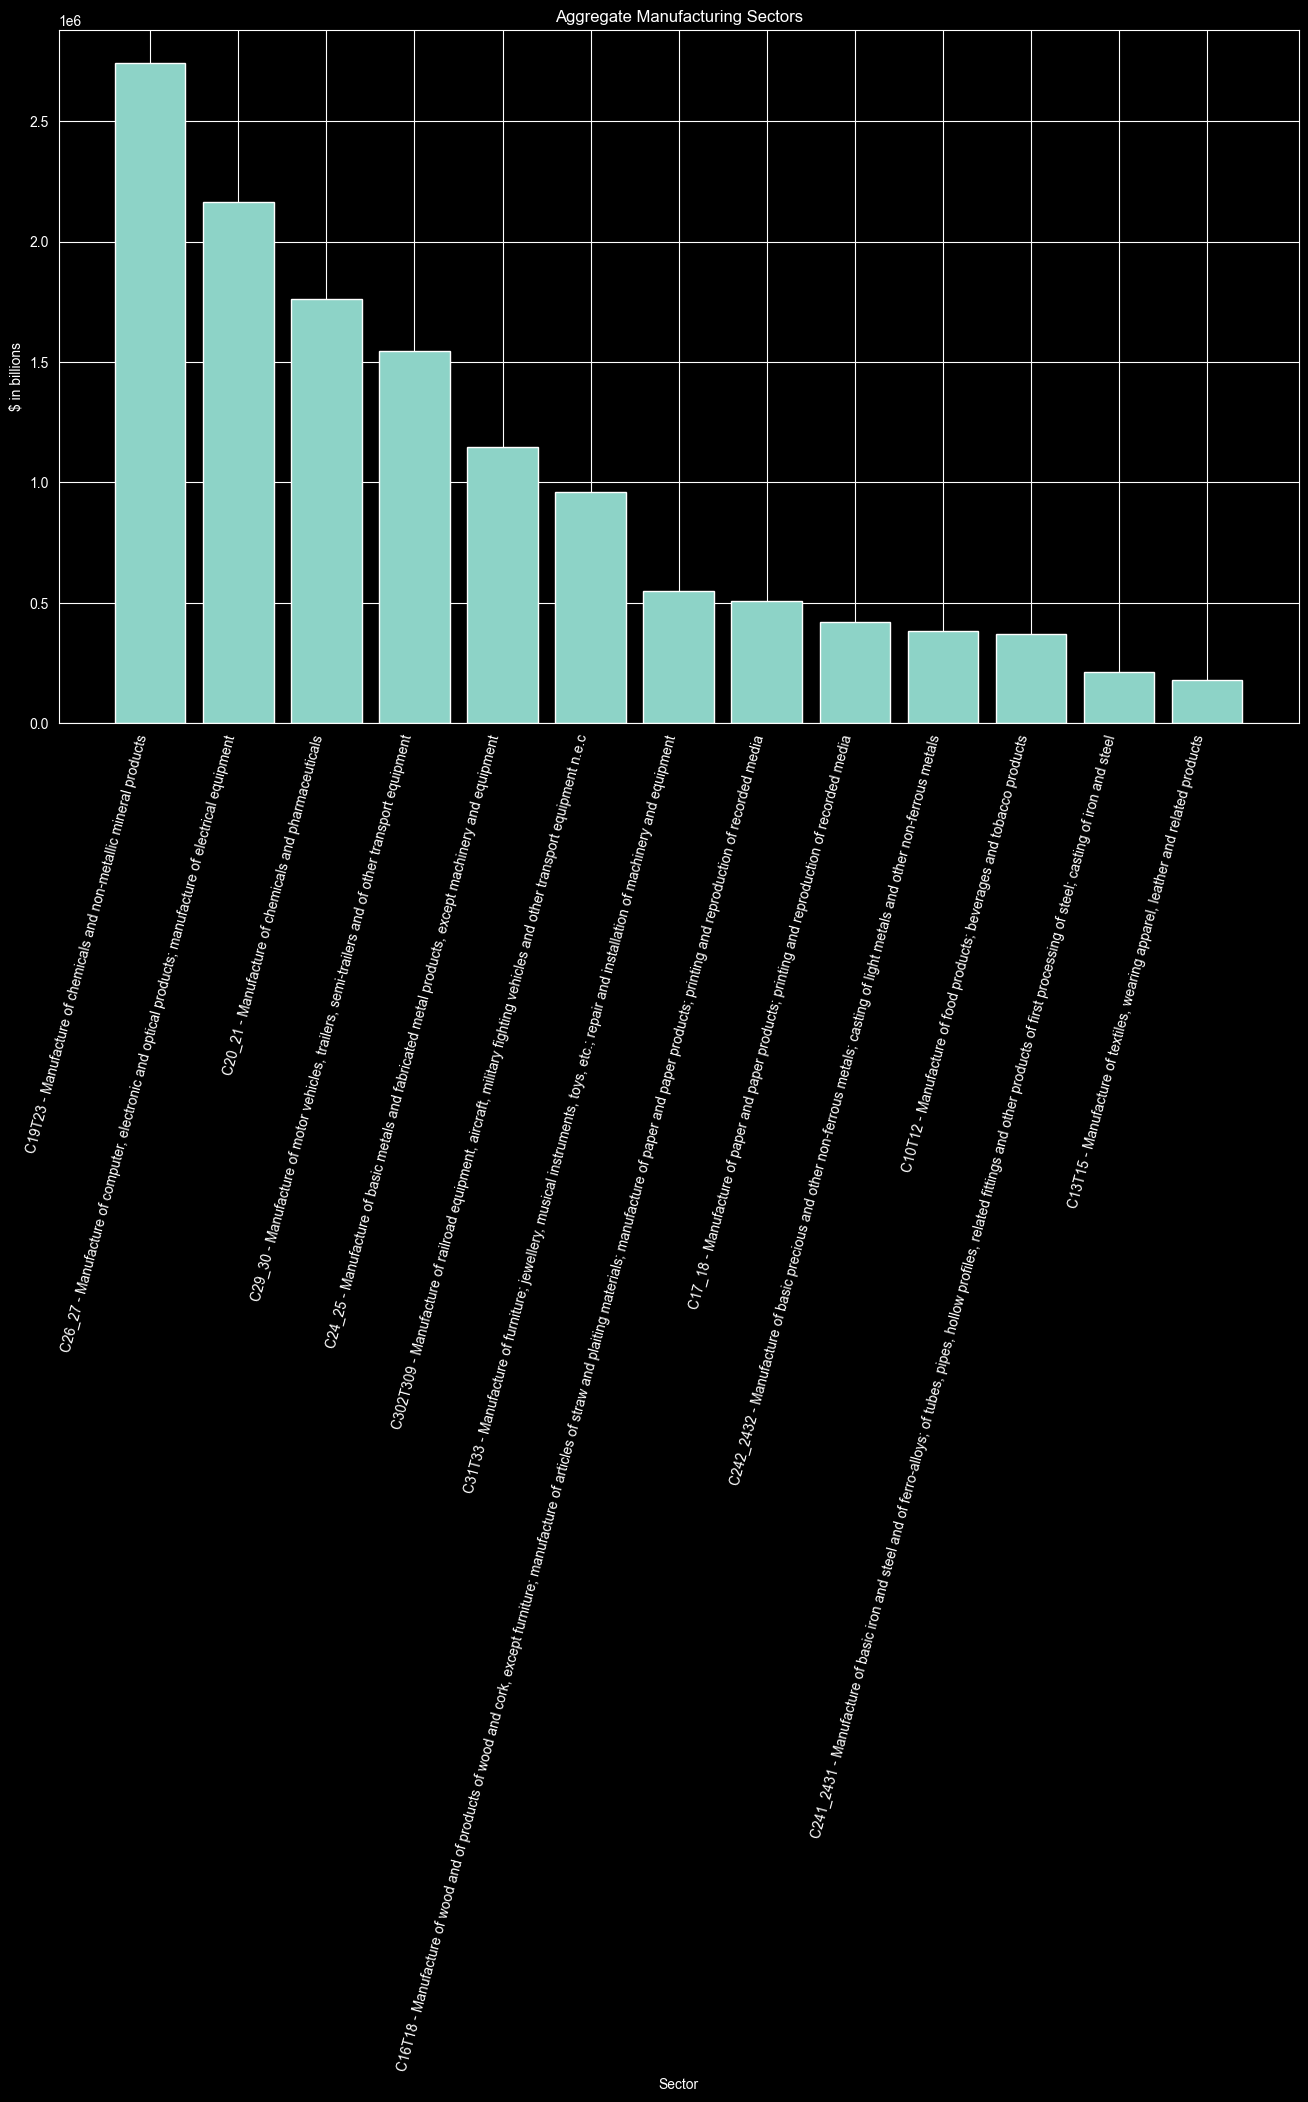

In [3]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = "/Users/brandon/Documents/ScratchProject/cleaned_us_manufacturing.csv"
df = pd.read_csv(file_path)


required_cols = ["ACTIVITY", "Economic activity", "OBS_VALUE"]
missing = [col for col in required_cols if col not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")


df["ACTIVITY"] = df["ACTIVITY"].astype(str).str.strip()
df["Economic activity"] = df["Economic activity"].astype(str).str.strip()
df["OBS_VALUE"] = pd.to_numeric(df["OBS_VALUE"], errors="coerce")
df = df.dropna(subset=["ACTIVITY", "Economic activity", "OBS_VALUE"])

# Create activity length column
df["activity_len"] = df["ACTIVITY"].str.len()

# Create combined label
df["sector_label"] = df["ACTIVITY"] + " - " + df["Economic activity"]


# Top 10 + Other

chart1_df = df[(df["activity_len"] >= 2) & (df["activity_len"] <= 4)].copy()

chart1_grouped = (
    chart1_df.groupby(["ACTIVITY", "Economic activity", "sector_label"], as_index=False)["OBS_VALUE"]
    .sum()
    .sort_values("OBS_VALUE", ascending=False)
)

top10_chart1 = chart1_grouped.head(10).copy()
other_total_chart1 = chart1_grouped.iloc[10:]["OBS_VALUE"].sum()

labels1 = top10_chart1["sector_label"].tolist()
sizes1 = top10_chart1["OBS_VALUE"].tolist()

if other_total_chart1 > 0:
    labels1.append("Other")
    sizes1.append(other_total_chart1)

# Pie Chart 1

plt.figure(figsize=(10, 10))
plt.pie(
    sizes1,
    labels=labels1,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.8,
    labeldistance=1.08
)
plt.title("Top 10 Manufacturing Sectors + Other")

plt.show()

# Bar Graph 1
plt.figure(figsize=(14, 8))
plt.bar(labels1, sizes1)
plt.title("Top 10 Manufacturing Sectors + Other")
plt.xlabel("Sector")
plt.ylabel("$ USD ")
plt.xticks(rotation=75, ha="right")

plt.show()



# ACTIVITY length greater than 4
# All aggregate sectors

chart2_df = df[df["activity_len"] > 4].copy()

chart2_grouped = (
    chart2_df.groupby(["ACTIVITY", "Economic activity", "sector_label"], as_index=False)["OBS_VALUE"]
    .sum()
    .sort_values("OBS_VALUE", ascending=False)
)

labels2 = chart2_grouped["sector_label"].tolist()
sizes2 = chart2_grouped["OBS_VALUE"].tolist()

# Pie Chart 2
plt.figure(figsize=(14, 14))
plt.pie(
    sizes2,
    labels=labels2,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.8,
    labeldistance=1.1
)
plt.title("Aggregate Manufacturing Sectors")
plt.show()

# Bar Graph 2
plt.figure(figsize=(16, 9))
plt.bar(labels2, sizes2)
plt.title("Aggregate Manufacturing Sectors")
plt.xlabel("Sector")
plt.ylabel("$ in billions")
plt.xticks(rotation=75, ha="right")

plt.show()